In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import AllChem
from scipy.spatial import distance
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import Chem, DataStructs

# Fig3

## Panel b, number of CPDs generated, high-scoring and tested

In [2]:
thresholds_positive = {"HEK": 0.8, "CAPAN": 0.6, "CAPAN2":0.65, "BXPC3": 0.6}

thresholds_negative = {"HEK": 0.6, "HEK2":0.7, "CAPAN": 0.2, "CFPAC": 0.2, "BXPC3": 0.2}

In [3]:
combinations = [
    "BXPC3_vs_CAPAN",
    "BXPC3_vs_HEK",
    "CAPAN_vs_HEK",
    "CAPAN_vs_CFPAC",
    "HEK_vs_BXPC3",
    "HEK_vs_CAPAN",
    "HEK_vs_CFPAC",
]

In [5]:
y_total = []
y_high_score = []
high_scoring_all = pd.DataFrame()
y_high_score_unique = []

for comb in combinations:
    cll1 = comb.split("_")[0]
    cll2 = comb.split("_")[2]
    
    df = pd.read_csv(f"../extra_data/generated_molecules/{comb}.csv")
    
    if cll2 == "HEK":
        if cll1 =='CAPAN':
            high_score = df[
            np.logical_and(
                df["raw_%s_classifier" % cll1] >= thresholds_positive[cll1+'2'],
                df["raw_%s_classifier" % cll2] >= thresholds_negative[cll2+'2'],
            )
        ]
        else:
            high_score = df[
                np.logical_and(
                    df["raw_%s_classifier" % cll1] >= thresholds_positive[cll1],
                    df["raw_%s_classifier" % cll2] >= thresholds_negative[cll2],
                )
            ]
    else:
        high_score = df[
            np.logical_and(
                df["raw_%s_classifier" % cll1] >= thresholds_positive[cll1],
                df["raw_%s_classifier" % cll2] <= thresholds_negative[cll2],
            )
        ]

    y_total.append(df.shape[0])
    y_high_score.append(high_score.shape[0])
    y_high_score_unique.append(high_score["inchi"].nunique())

    high_score["exercise"] = cll1 + "_vs_" + cll2
    
    # 4. Also replace the very last append with pd.concat
    high_scoring_all = pd.concat([high_scoring_all, high_score])


/tmp/ipykernel_46771/3402518857.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_score["exercise"] = cll1 + "_vs_" + cll2
/tmp/ipykernel_46771/3402518857.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_score["exercise"] = cll1 + "_vs_" + cll2
/tmp/ipykernel_46771/3402518857.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.or

In [6]:
cpds_bought = {
    "BXPC3_vs_CAPAN": 16,
    "BXPC3_vs_HEK": 22,
    "CAPAN_vs_HEK": 1,
    "CAPAN_vs_CFPAC": 1,
    "HEK_vs_CAPAN": 1,
    "HEK_vs_BXPC3": 1,
    "HEK_vs_CFPAC": 11,
}

In [7]:
y_bought = [cpds_bought[comb] for comb in combinations]

In [8]:
labels = [
    "BXPC3 vs CAPAN2",
    "BXPC3 vs HEK293",
    "CAPAN2 vs HEK293",
    "CAPAN2 vs CFPAC1",
    "HEK293 vs BXPC3",
    "HEK293 vs CAPAN2",
    "HEK293 vs CFPAC1",
]

In [9]:
irb_library = pd.read_csv(
    "../extra_data/irb_library2.csv"
)
y_irb = irb_library.shape[0] - 11053

In [10]:
y_irb

133672

In [11]:
# Function to compute Morgan fingerprints
def compute_morgan_fingerprints(inchi_list):
    fingerprints = []
    for inchi in inchi_list:
        mol = Chem.MolFromInchi(inchi)
        fingerprint = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
        fingerprints.append(fingerprint)

    return np.array(fingerprints)


from scipy.spatial.distance import pdist, squareform

In [12]:
high_scoring_all.drop_duplicates(inplace=True)
high_scoring_all

,smiles,inchi,total_score,raw_BXPC3_classifier,raw_CAPAN_classifier,exercise,raw_HEK_classifier,raw_CFPAC_classifier
4,c1cncc(CNC(=O)c2cc3c(cc2)Sc2c(cc(C)cc2)C(C)=N3)c1,InChI=1S/C22H19N3OS/c1-14-5-7-20-18(10-14)15(2...,0.935703,0.73,0.09,BXPC3_vs_CAPAN,NaN,NaN
36,c1cc(-c2ccc(Cl)cc2)ccc1CNC(=O)c1cc2c(cc1)Sc1c(...,InChI=1S/C29H23ClN2OS/c1-18-3-13-27-25(15-18)1...,0.932706,0.73,0.10,BXPC3_vs_CAPAN,NaN,NaN
45,c1cc(-c2ccsc2)ccc1CNC(=O)c1cc2c(cc1)Sc1c(cc(C)...,InChI=1S/C27H22N2OS2/c1-17-3-9-25-23(13-17)18(...,0.900635,0.65,0.04,BXPC3_vs_CAPAN,NaN,NaN
50,c1cccc(-c2ccc(C)cc2)c1CNC(=O)c1cc2c(cc1)Sc1c(c...,InChI=1S/C30H26N2OS/c1-19-8-11-22(12-9-19)25-7...,0.966822,0.81,0.05,BXPC3_vs_CAPAN,NaN,NaN
53,c1cccc(-c2ccccc2)c1CNC(=O)c1cc2c(cc1)Sc1c(cc(C...,InChI=1S/C29H24N2OS/c1-19-12-14-27-25(16-19)20...,0.914245,0.68,0.08,BXPC3_vs_CAPAN,NaN,NaN
...,...,...,...,...,...,...,...,...
6689,c1ccc(N=c2[nH]c(N3CCOCC3)cc(C)n2)cc1NS(=O)(c1c...,InChI=1S/C21H22ClN5O3S/c1-15-13-20(27-9-11-30-...,0.821970,NaN,NaN,HEK_vs_CFPAC,0.86,0.19
6860,c1c(N=c2[nH]c(N3CCCCCC3)cc(C)n2)ccc(C(=O)N2CCO...,InChI=1S/C22H29N5O2/c1-17-16-20(26-10-4-2-3-5-...,0.838816,NaN,NaN,HEK_vs_CFPAC,0.81,0.17
7070,c1cccc(N=c2[nH]c(N3CCOCC3)cc(C)n2)c1NC(c1ccc(N...,InChI=1S/C28H34N6O2/c1-21-20-26(34-16-18-36-19...,0.869507,NaN,NaN,HEK_vs_CFPAC,0.80,0.14
7073,c1cc(N=c2[nH]c(N3CCOCCC3)cc(C)n2)ccc1NC(=O)C1CCC1,InChI=1S/C21H27N5O2/c1-15-14-19(26-10-3-12-28-...,0.843437,NaN,NaN,HEK_vs_CFPAC,0.82,0.17


In [13]:
mfps_unique = compute_morgan_fingerprints(high_scoring_all.inchi.values)
distances_high_scoring = pdist(mfps_unique, metric="jaccard")

[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerat

[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerator
[17:44:52] DEPRECATION WARNING: please use MorganGenerat

In [14]:
np.mean(distances_high_scoring)

np.float64(0.8367657578646793)

In [15]:
# Closest active

actives = pd.read_excel(
    "../../drug screening data/HTS_and_confirmation.xlsx", sheet_name="Training set"
)

cell_line_columns = [col for col in actives.columns if col.startswith("positives ")]
actives_f = actives[actives[cell_line_columns].eq(1).any(axis=1)]

enumerator = rdMolStandardize.TautomerEnumerator()


def compute_max_tanimoto(query_cpds, cpds_to_compare, remove_closest=False):
    """The first array must be the query one, and the second one, the one to compare with"""
    # Get the molecules
    mols_A = [enumerator.Canonicalize(Chem.MolFromInchi(s)) for s in query_cpds]
    mols_A = list(np.array(mols_A)[np.array(mols_A) != None])
    mols_B = [enumerator.Canonicalize(Chem.MolFromSmiles(s)) for s in cpds_to_compare]
    # Compute Morgan fingerprints
    fps_A = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols_A]
    fps_B = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols_B]
    # Compute tanimoto similarity and take max one
    max_sims, index_closest = [], []
    for fp in fps_A:
        sims = np.array(DataStructs.BulkTanimotoSimilarity(fp, fps_B))
        sorted_indices = np.argsort(sims)
        sims = sims[sorted_indices]
        if remove_closest:
            sims = sims[:-1]
            sorted_indices = sorted_indices[:-1]
        max_sims.append(sims[-1])
        index_closest.append(sorted_indices[-1])
    return np.array(max_sims), np.array(index_closest)


# Look for the closest active
active_smiles = actives_f["SMILES"].values
tanimotos_actives, indexes_closest_active = compute_max_tanimoto(
    high_scoring_all["inchi"], active_smiles
)

[17:45:03] Tautomer enumeration stopped at 184 tautomers: max transforms reached
[17:45:04] Tautomer enumeration stopped at 468 tautomers: max transforms reached
[17:45:05] Tautomer enumeration stopped at 187 tautomers: max transforms reached
[17:45:06] Tautomer enumeration stopped at 200 tautomers: max transforms reached
[17:45:08] Tautomer enumeration stopped at 296 tautomers: max transforms reached
[17:45:09] Tautomer enumeration stopped at 193 tautomers: max transforms reached
[17:45:10] Tautomer enumeration stopped at 290 tautomers: max transforms reached
[17:45:10] Tautomer enumeration stopped at 450 tautomers: max transforms reached
[17:45:12] Tautomer enumeration stopped at 206 tautomers: max transforms reached
[17:45:12] Tautomer enumeration stopped at 230 tautomers: max transforms reached
[17:45:14] Tautomer enumeration stopped at 185 tautomers: max transforms reached
[17:45:14] Tautomer enumeration stopped at 132 tautomers: max transforms reached
[17:45:16] Tautomer enumerat

In [16]:
actives.columns

Index(['SMILES', 'Supplier', 'Supplier Ref', 'CLNUMBER', 'Conc', '%Inh CAPAN2',
       '%Inh SW1990', '%Inh BXPC3', '%Inh HPAFII', '%Inh CFPAC1',
       '%Inh PANC10.05', '%Inh AsPC-1', '%Inh U2OS', '%Inh HEK293',
       'positives CAPAN2', 'positives SW1990', 'positives BXPC3',
       'positives HPAFII', 'positives CFPAC1', 'positives PANC10.05',
       'positives AsPC-1', 'positives U2OS', 'positives HEK293'],
      dtype='object')

In [17]:
actives_f.shape

(445, 23)

In [18]:
len(tanimotos_actives)

661

## IRB compounds tested: tanimotos

In [19]:
map_names = {
    'BXPC3': 'BXPC3',
    'CAPAN': 'CAPAN2',
    'CFPAC': 'CFPAC1',
    'HEK': 'HEK293',
}

In [20]:
thresholds_positive = {"HEK": 0.8, "CAPAN": 0.6, "BXPC3": 0.6}

thresholds_negative = {"HEK": 0.6, "CAPAN": 0.2, "CFPAC": 0.2, "BXPC3": 0.2}

In [21]:
high_scoring_irb = pd.DataFrame()
for comb in combinations:
    pos_cll = comb.split("_")[0]
    neg_cll = comb.split("_")[2]
    df = pd.read_csv(
        "../extra_data/prediction_scores_IRB_library/%s_vs_%s.csv"
        % (map_names[pos_cll], map_names[neg_cll])
    )
    if neg_cll == "HEK":
        df_f = df[
            np.logical_and(
                df["raw_%s_classifier" % pos_cll] >= thresholds_positive[pos_cll],
                df["raw_%s_classifier" % neg_cll] >= thresholds_negative[neg_cll],
            )
        ]
    else:
        df_f = df[
            np.logical_and(
                df["raw_%s_classifier" % pos_cll] >= thresholds_positive[pos_cll],
                df["raw_%s_classifier" % neg_cll] <= thresholds_negative[neg_cll],
            )
        ]

    high_scoring_irb = pd.concat([high_scoring_irb, df_f], ignore_index=True)

high_scoring_irb = high_scoring_irb.merge(
    irb_library, right_on="SMILES", left_on="smiles"
)
high_scoring_irb = high_scoring_irb[
    ~np.isin(high_scoring_irb["IDNUMBER"], actives["Supplier Ref"])
]

In [22]:
mfps_unique_irb = compute_morgan_fingerprints(
    [Chem.MolToInchi(Chem.MolFromSmiles(s)) for s in high_scoring_irb["SMILES"].values]
)
distances_high_scoring_irb = pdist(mfps_unique_irb, metric="jaccard")

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Charges were rearranged

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefined stereo

[17:46:33] WARNING: Omitted undefin

In [23]:
distances_high_scoring_irb

array([0.91304348, 0.81927711, 0.86666667, ..., 0.94505495, 0.80263158,
       0.86904762], shape=(2145,))

In [24]:
# Closest active
from rdkit.Chem import AllChem
from scipy.spatial import distance
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import Chem, DataStructs

enumerator = rdMolStandardize.TautomerEnumerator()


def compute_max_tanimoto(query_cpds, cpds_to_compare, remove_closest=False):
    """The first array must be the query one, and the second one, the one to compare with"""
    # Get the molecules
    mols_A = [enumerator.Canonicalize(Chem.MolFromSmiles(s)) for s in query_cpds]
    mols_A = list(np.array(mols_A)[np.array(mols_A) != None])
    mols_B = [enumerator.Canonicalize(Chem.MolFromSmiles(s)) for s in cpds_to_compare]
    # Compute Morgan fingerprints
    fps_A = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols_A]
    fps_B = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols_B]
    # Compute tanimoto similarity and take max one
    max_sims, index_closest = [], []
    for fp in fps_A:
        sims = np.array(DataStructs.BulkTanimotoSimilarity(fp, fps_B))
        sorted_indices = np.argsort(sims)
        sims = sims[sorted_indices]
        if remove_closest:
            sims = sims[:-1]
            sorted_indices = sorted_indices[:-1]
        max_sims.append(sims[-1])
        index_closest.append(sorted_indices[-1])
    return np.array(max_sims), np.array(index_closest)


# Look for the closest active
tanimotos_actives_irb, indexes_closest_active = compute_max_tanimoto(
    high_scoring_irb["smiles"], active_smiles
)

[17:46:34] Can't kekulize mol.  Unkekulized atoms: 4 9 10 18
[17:46:34] Can't kekulize mol.  Unkekulized atoms: 7 8 9 14 32
[17:46:34] Can't kekulize mol.  Unkekulized atoms: 7 8 9 14 32
[17:46:34] Can't kekulize mol.  Unkekulized atoms: 7 8 9 14 32
[17:46:34] Can't kekulize mol.  Unkekulized atoms: 2 12
[17:46:34] Can't kekulize mol.  Unkekulized atoms: 2 12
[17:46:35] Can't kekulize mol.  Unkekulized atoms: 7 11
[17:46:38] Can't kekulize mol.  Unkekulized atoms: 11 22
[17:46:38] Can't kekulize mol.  Unkekulized atoms: 11 22
[17:46:38] Can't kekulize mol.  Unkekulized atoms: 11 22
[17:46:38] Can't kekulize mol.  Unkekulized atoms: 2 12
[17:46:38] Can't kekulize mol.  Unkekulized atoms: 16 20
[17:46:38] Can't kekulize mol.  Unkekulized atoms: 7 11
[17:46:38] Can't kekulize mol.  Unkekulized atoms: 8 12
[17:46:38] Can't kekulize mol.  Unkekulized atoms: 4 8
[17:46:38] Can't kekulize mol.  Unkekulized atoms: 4 8
[17:46:39] DEPRECATION WARNING: please use MorganGenerator
[17:46:39] DEPREC

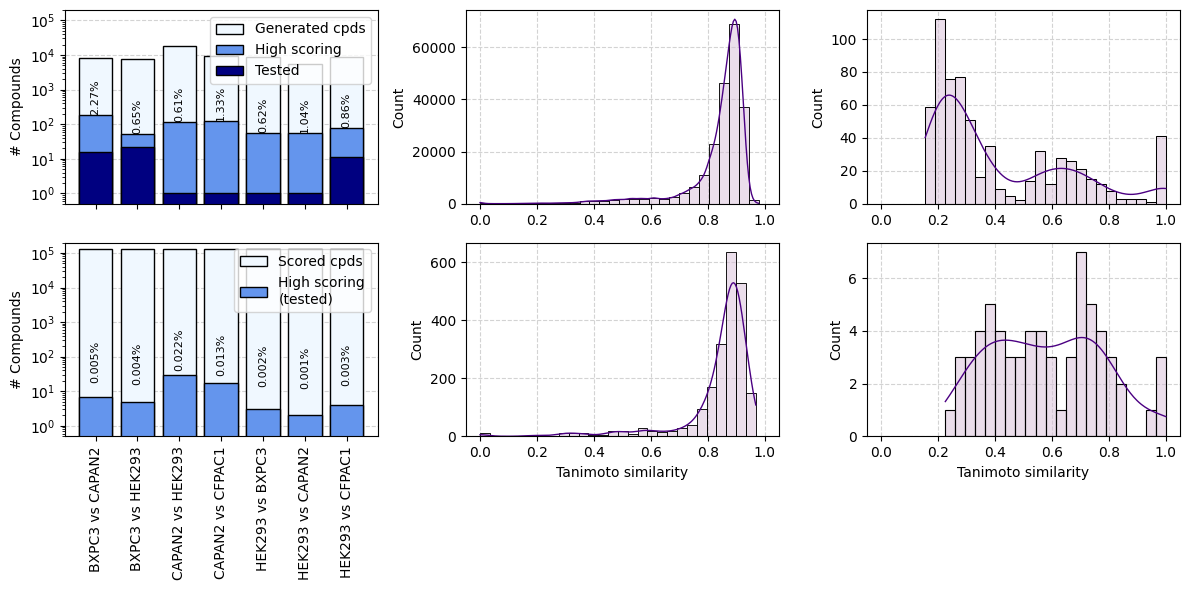

In [25]:
import seaborn as sns
from matplotlib.ticker import LogLocator

import matplotlib.pyplot as plt

# Convert mm to inches (matplotlib uses inches)
width_mm = 120
width_inches = width_mm / 25.4

# Create the figure with the specified width
fig, [[ax1, ax2, ax3], [ax4, ax5, ax6]] = plt.subplots(2, 3, figsize=(12, 6))
x = np.arange(0, 7, 1)
colors = ["aliceblue", "cornflowerblue", "navy"]

# Plot the bar plot for generated mols
ax1.bar(
    x,
    y_total,
    color=colors[0],
    edgecolor="black",
    label="Generated cpds",
    zorder=2,
)

ax1.bar(
    x, y_high_score, color=colors[1], edgecolor="black", label="High scoring", zorder=2
)

ax1.bar(x, y_bought, color=colors[2], edgecolor="black", label="Tested", zorder=2)

ax1.set_xticks(x, labels=[], rotation=90)
ax1.set_ylabel("# Compounds")

ax1.legend()
ax1.grid(axis="y", ls="--", c="lightgrey", zorder=0)
# plt.tight_layout()

ax1.set_yscale("log")

# Set minor ticks for ax1
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=10))
ax1.yaxis.set_minor_formatter(plt.NullFormatter())

# Write percentages of high scoring compounds on top of each bar
values = np.array(y_high_score) / np.array(y_total) * 100
for i in x:
    bar_height = y_high_score[i]
    ax1.text(
        i,
        bar_height,
        "%.2f%%" % values[i],
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90,
    )

# Plot bar plot for IRB library
ax4.bar(
    x,
    [y_irb] * 7,
    color=colors[0],
    edgecolor="black",
    label="Scored cpds",
    zorder=2,
)
y_high_scoring_irb = [7, 5, 29, 17, 3, 2, 4]
ax4.bar(
    x,
    y_high_scoring_irb,
    color=colors[1],
    edgecolor="black",
    label="High scoring\n(tested)",
    zorder=2,
)

ax4.set_xticks(x, labels=labels, rotation=90)
ax4.set_ylabel("# Compounds")

ax4.legend()
ax4.grid(axis="y", ls="--", c="lightgrey", zorder=0)
# Write percentages of high scoring compounds on top of each bar
values = np.array(y_high_scoring_irb) / np.array(y_irb) * 100
for i in x:
    bar_height = y_high_scoring_irb[i]
    ax4.text(
        i,
        bar_height + 10,
        "%.3f%%" % values[i],
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90,
    )

ax4.set_yscale("log")

# Set minor ticks for ax4
ax4.yaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=10))
ax4.yaxis.set_minor_formatter(plt.NullFormatter())

# Plot the histograms with the tanimotos

sns.histplot(
    distances_high_scoring, kde=True, zorder=2, ax=ax2, binwidth=0.035, color="thistle"
)
kde_line = ax2.lines[0]
kde_line.set_color("indigo")
kde_line.set_linewidth(1)

sns.histplot(
    tanimotos_actives, kde=True, zorder=2, ax=ax3, binwidth=0.035, color="thistle"
)
kde_line = ax3.lines[0]
kde_line.set_color("indigo")
kde_line.set_linewidth(1)

sns.histplot(
    distances_high_scoring_irb,
    kde=True,
    zorder=2,
    ax=ax5,
    binwidth=0.035,
    color="thistle",
)
kde_line = ax5.lines[0]
kde_line.set_color("indigo")
kde_line.set_linewidth(1)


sns.histplot(
    tanimotos_actives_irb, kde=True, zorder=2, ax=ax6, binwidth=0.035, color="thistle"
)
kde_line = ax6.lines[0]
kde_line.set_color("indigo")
kde_line.set_linewidth(1)

ax2.grid(axis="both", ls="--", c="lightgrey", zorder=0)
ax3.grid(axis="both", ls="--", c="lightgrey", zorder=0)
ax6.grid(axis="both", ls="--", c="lightgrey", zorder=0)
ax5.grid(axis="both", ls="--", c="lightgrey", zorder=0)

ax5.set_xlabel("Tanimoto similarity")
ax6.set_xlabel("Tanimoto similarity")

for ax in [ax2, ax3, ax5, ax6]:
    ax.set_xlim(-0.05, 1.05)

for ax in [ax1, ax4]:
    ax.set_ylim(0.5, 200000)
    ax.set_yticks([1, 10, 100, 1000, 10000, 100000])

# Adjust the spacing between subplots
plt.tight_layout()

plt.show()

# Supplementary figure 9: repetitive scaffold

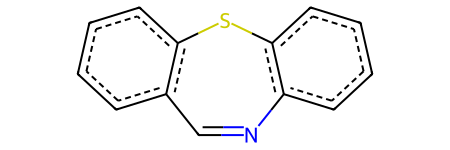

In [26]:
smarts = "[#6]:1(:[#6]:[#6]-2:[#6](-[#16]-[#6]:3:[#6](-[#6](=[#7]-2)):[#6]:[#6](:[#6]:[#6]:3)):[#6]:[#6]:1)"
Chem.MolFromSmarts(smarts)